In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Appliances energy prediction 

The goal is to predict the consommation (ie the "appliance") of a low energy building, using also the outside temperature. 

In [2]:
df = pd.read_csv("data/energydata_complete.csv")

df["date"] = pd.to_datetime(df["date"])

# Keep relevant columns and rows
df = df[["date", "Appliances", "T_out"]].dropna().sort_values("date")

df.head()

,date,Appliances,T_out
0,2016-01-11 17:00:00,60,6.600000
1,2016-01-11 17:10:00,60,6.483333
2,2016-01-11 17:20:00,50,6.366667
3,2016-01-11 17:30:00,50,6.250000
4,2016-01-11 17:40:00,60,6.133333


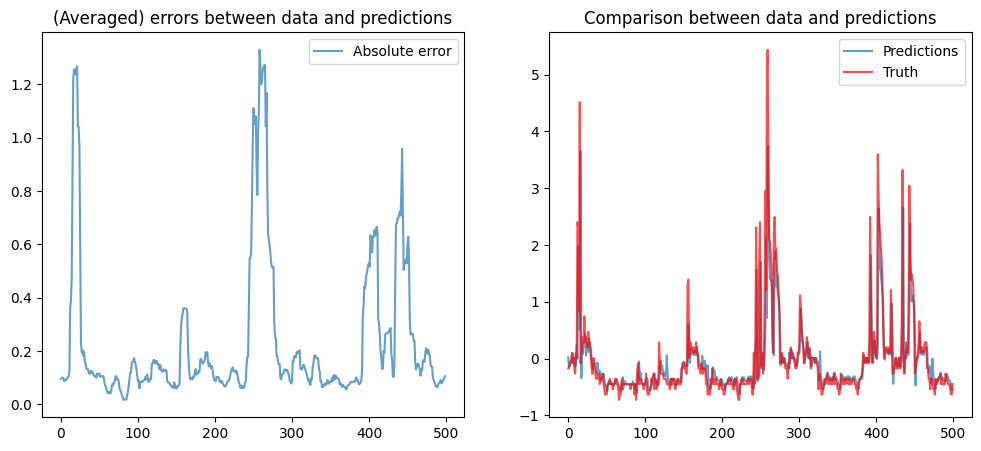

In [3]:
from ctw.models import BivariateQuantizer, BivariateARTree
from ctw.tree import view_tree

## Parameters
n_samples = 10_000
max_depth = 3
order = 2

seq_x = np.array(df["Appliances"][:n_samples].tolist())
seq_y = np.array(df["T_out"][:n_samples].tolist())

# preprocessing 
seq_x = (seq_x - np.mean(seq_x))/ np.std(seq_x)
seq_y = (seq_y - np.mean(seq_y)) / np.std(seq_y)


# take thresholds based on quantiles 
qx = np.quantile(seq_x,[0.33, 0.66])
qy = np.quantile(seq_y,[0.33, 0.66])

thresholds = np.array([qx, qy], dtype=float)

bq = BivariateQuantizer(thresholds=thresholds)
tree = BivariateARTree(order=order, max_depth=max_depth, quantizer=bq, beta = 0.5)

for x, y in zip(seq_x[:order], seq_y[:order]) :
    tree.observe(x, y)

# Draw error curve between predicted and actual values

predictions = []
actuals = []
for x_i, y_i in zip(seq_x[order:], seq_y[order:]):
    history = np.array([tree._x[-max_depth:], tree._y[-max_depth:]])
    prediction = tree.predict(history)
    predictions.append(prediction)
    actuals.append(x_i)
    tree.observe(x_i, y_i)
    
errors = [abs((p - a)) for p, a in zip(predictions, actuals)]
window = 10  
error_avg = np.convolve(errors, np.ones(window)/window, mode='valid')

data_to_plot = 500  # len(errors)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(error_avg[-data_to_plot:], label = "Absolute error", alpha = 0.7)
plt.legend()
plt.title("(Averaged) errors between data and predictions")

plt.subplot(1, 2, 2)
plt.plot(predictions[-data_to_plot:], label = "Predictions", alpha = 0.7)
plt.plot(actuals[-data_to_plot:], label = "Truth", alpha = 0.7, color = "red")
plt.legend()
plt.title("Comparison between data and predictions")

view_tree(tree.tree,quantizer=bq)

In [4]:
mse = np.mean((np.array(actuals) - np.array(predictions)) ** 2)
mse

np.float64(0.442771929290765)

In [5]:
errors = np.abs(np.array(actuals) - np.array(predictions))
mae = errors.mean()
print("Test MAE:", mae)

Test MAE: 0.293623880755474


Test MAE: 0.295768034148796


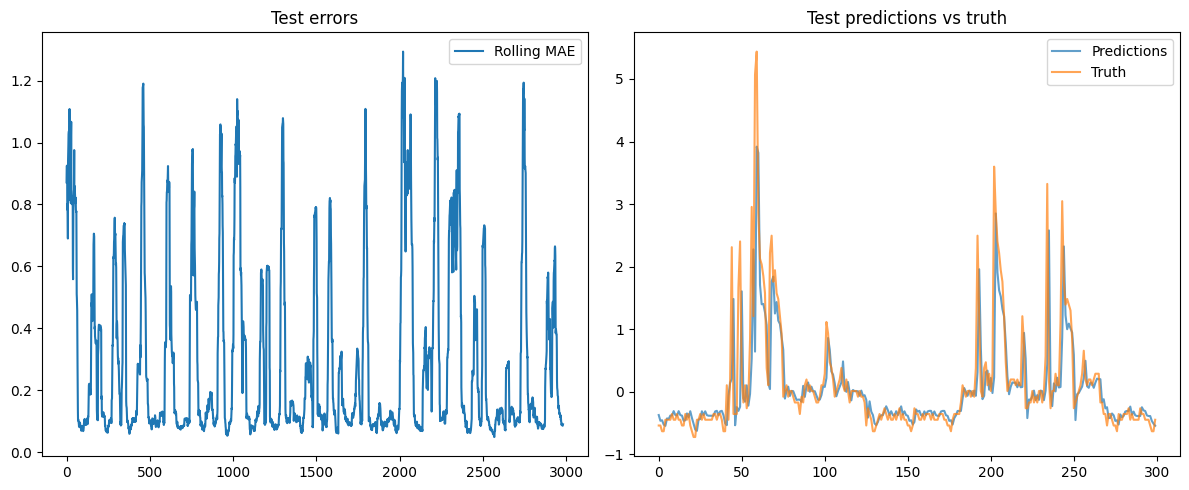

In [6]:
n_samples = 10_000
max_depth = 3
order = 2

seq_x = np.array(df["Appliances"][:n_samples], dtype=float)
seq_y = np.array(df["T_out"][:n_samples], dtype=float)

# normalisation
seq_x = (seq_x - np.mean(seq_x)) / np.std(seq_x)
seq_y = (seq_y - np.mean(seq_y)) / np.std(seq_y)

# split chronologique
split_idx = int(0.7 * len(seq_x))

x_train, x_test = seq_x[:split_idx], seq_x[split_idx:]
y_train, y_test = seq_y[:split_idx], seq_y[split_idx:]
qx = np.quantile(x_train, [0.33, 0.66])
qy = np.quantile(y_train, [0.33, 0.66])
thresholds = np.array([qx, qy], dtype=float)

bq = BivariateQuantizer(thresholds=thresholds)
tree = BivariateARTree(order=order, max_depth=max_depth, quantizer=bq, beta=0.5)

# train 
for x_i, y_i in zip(x_train, y_train):
    tree.observe(x_i, y_i)

predictions = []
actuals = []

for x_i, y_i in zip(x_test, y_test):
    history = np.array([
        tree._x[-max_depth:],
        tree._y[-max_depth:]
    ], dtype=float)

    pred = tree.predict(history)
    predictions.append(pred)
    actuals.append(x_i)

    # mise à jour online avec la vraie observation test
    tree.observe(x_i, y_i)

errors = np.abs(np.array(predictions) - np.array(actuals))
mae = errors.mean()
print("Test MAE:", mae)


window = 20
error_avg = np.convolve(errors, np.ones(window) / window, mode="valid")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(error_avg, label="Rolling MAE")
plt.legend()
plt.title("Test errors")

plt.subplot(1, 2, 2)
plt.plot(predictions[-300:], label="Predictions", alpha=0.7)
plt.plot(actuals[-300:], label="Truth", alpha=0.7)
plt.legend()
plt.title("Test predictions vs truth")

plt.tight_layout()
plt.show()

In [7]:
# split chronologique
split_idx = int(0.7 * len(seq_x))

predictions = []
actuals = []

prev_x = x_train[-1]  # dernière valeur vue dans le train

for x_i in seq_x:
    pred = prev_x
    predictions.append(pred)
    actuals.append(x_i)
    prev_x = x_i

predictions = np.array(predictions)
actuals = np.array(actuals)

mae = np.mean(np.abs(predictions - actuals))
mse = np.mean((predictions - actuals) ** 2)

print("Naive baseline - MAE:", mae)
print("Naive baseline - MSE:", mse)

Naive baseline - MAE: 0.29344761494096594
Naive baseline - MSE: 0.4765182810421149


# 2. Household Electric Power Consumption 

The goal is to predict ..

In [8]:
df = pd.read_csv(
    "data/household_power_consumption.txt",
    sep=";",         
    na_values="?",   
    low_memory=False 
)

df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)
cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

df[cols] = df[cols].astype(float)
df = df.dropna()
df = df[["datetime", "Global_active_power", "Voltage"]]
df = df.sort_values("datetime").reset_index(drop=True)
df.head()

,datetime,Global_active_power,Voltage
0,2006-12-16 17:24:00,4.216,234.84
1,2006-12-16 17:25:00,5.360,233.63
2,2006-12-16 17:26:00,5.374,233.29
3,2006-12-16 17:27:00,5.388,233.74
4,2006-12-16 17:28:00,3.666,235.68


Test MAE: 0.25820817917629824


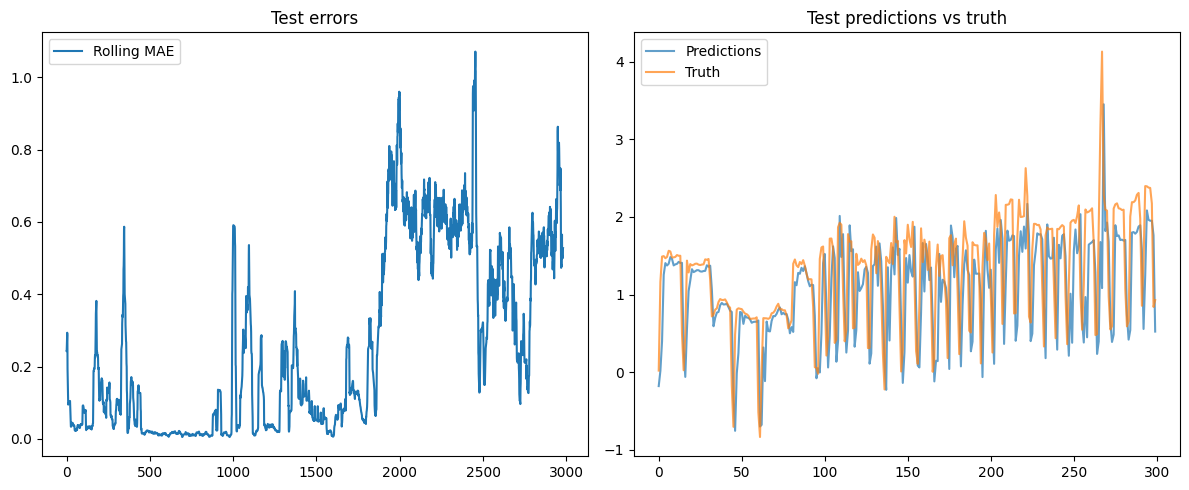

In [9]:
n_samples = 10_000
max_depth = 3
order = 2

seq_x = np.array(df["Global_active_power"][:n_samples], dtype=float)
seq_y = np.array(df["Voltage"][:n_samples], dtype=float)

# normalisation
seq_x = (seq_x - np.mean(seq_x)) / np.std(seq_x)
seq_y = (seq_y - np.mean(seq_y)) / np.std(seq_y)

# split chronologique
split_idx = int(0.7 * len(seq_x))

x_train, x_test = seq_x[:split_idx], seq_x[split_idx:]
y_train, y_test = seq_y[:split_idx], seq_y[split_idx:]
qx = np.quantile(x_train, [0.33, 0.66])
qy = np.quantile(y_train, [0.33, 0.66])
thresholds = np.array([qx, qy], dtype=float)

bq = BivariateQuantizer(thresholds=thresholds)
tree = BivariateARTree(order=order, max_depth=max_depth, quantizer=bq, beta=0.5)

# train 
for x_i, y_i in zip(x_train, y_train):
    tree.observe(x_i, y_i)

predictions = []
actuals = []

for x_i, y_i in zip(x_test, y_test):
    history = np.array([
        tree._x[-max_depth:],
        tree._y[-max_depth:]
    ], dtype=float)

    pred = tree.predict(history)
    predictions.append(pred)
    actuals.append(x_i)

    # mise à jour online avec la vraie observation test
    tree.observe(x_i, y_i)

errors = np.abs(np.array(predictions) - np.array(actuals))
mae = errors.mean()
print("Test MAE:", mae)


window = 20
error_avg = np.convolve(errors, np.ones(window) / window, mode="valid")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(error_avg, label="Rolling MAE")
plt.legend()
plt.title("Test errors")

plt.subplot(1, 2, 2)
plt.plot(predictions[-300:], label="Predictions", alpha=0.7)
plt.plot(actuals[-300:], label="Truth", alpha=0.7)
plt.legend()
plt.title("Test predictions vs truth")

plt.tight_layout()
plt.show()

In [10]:
predictions = []
actuals = []

prev_x = x_train[-1]  # dernière valeur vue dans le train

for x_i in seq_x:
    pred = prev_x
    predictions.append(pred)
    actuals.append(x_i)
    prev_x = x_i

predictions = np.array(predictions)
actuals = np.array(actuals)

mae = np.mean(np.abs(predictions - actuals))
mse = np.mean((predictions - actuals) ** 2)

print("Naive baseline - MAE:", mae)
print("Naive baseline - MSE:", mse)

Naive baseline - MAE: 0.16012676845916365
Naive baseline - MSE: 0.14296084523889027
